In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [19]:
df = pd.read_csv("../data/train.csv")

df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [20]:
print(df.shape)

print(df.info())

print(df.isnull().sum())

print(df.duplicated().sum())

(10886, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB
None
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64
0


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
df["datetime"] = pd.to_datetime(
    df["datetime"]
)

df["year"] = df["datetime"].dt.year

df["month"] = df["datetime"].dt.month

df["day"] = df["datetime"].dt.day

df["hour"] = df["datetime"].dt.hour

df["dayofweek"] = (
    df["datetime"].dt.dayofweek
)

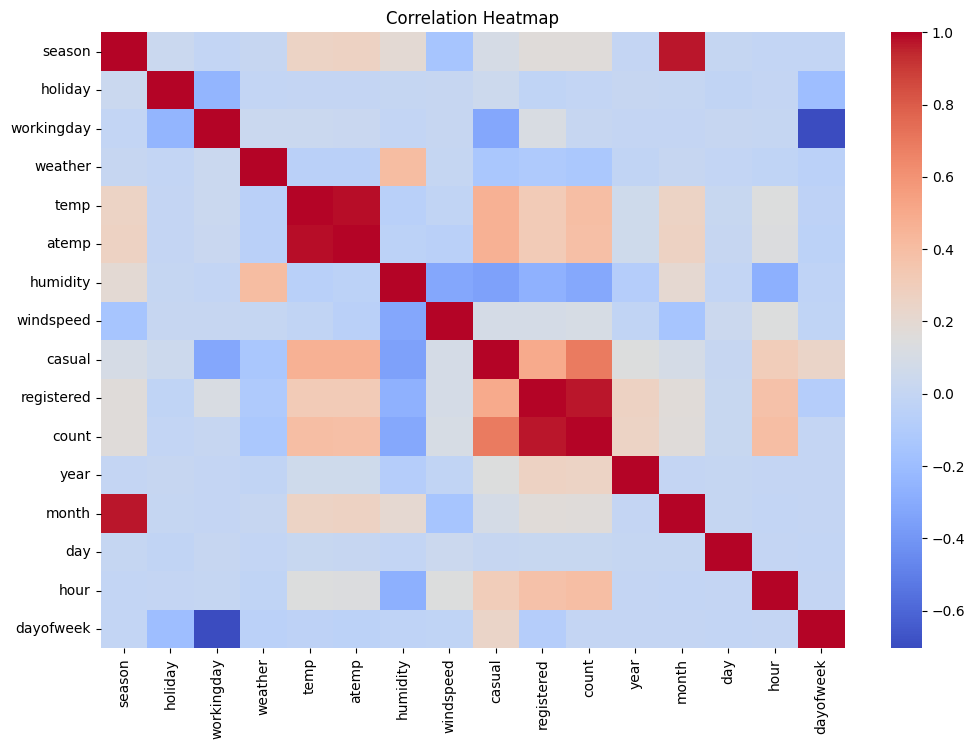

In [23]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig(
    "../outputs/correlation_heatmap.png"
)

plt.show()

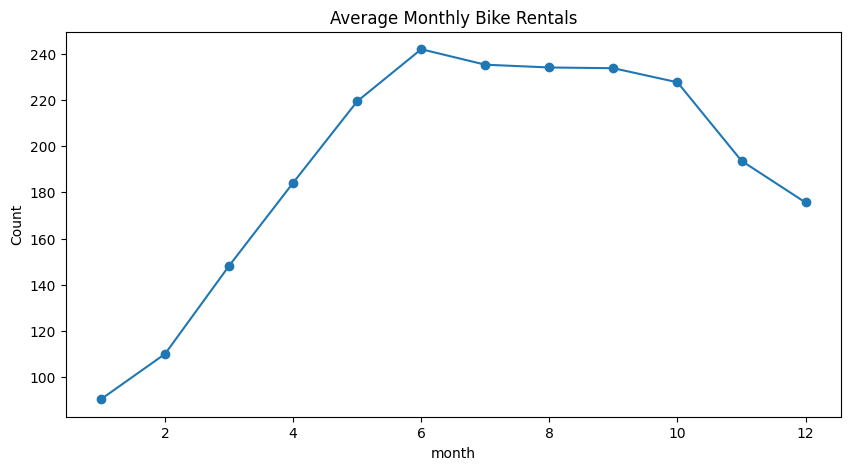

In [24]:
monthly = df.groupby(
    "month"
)["count"].mean()

monthly.plot(
    figsize=(10,5),
    marker="o"
)

plt.title(
    "Average Monthly Bike Rentals"
)

plt.ylabel("Count")

plt.show()

In [25]:
features = [

    "season",

    "holiday",

    "workingday",

    "weather",

    "temp",

    "atemp",

    "humidity",

    "windspeed",

    "year",

    "month",

    "day",

    "hour",

    "dayofweek"
]

In [26]:
X = df[features]

y = df["count"]

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
models = {

    "Linear Regression":
    LinearRegression(),

    "Decision Tree":
    DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest":
    RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingRegressor(
        random_state=42
    )
}

In [29]:
results = []

for name, model in models.items():

    model.fit(
        X_train,
        y_train
    )

    pred = model.predict(
        X_test
    )

    mae = mean_absolute_error(
        y_test,
        pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            pred
        )
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append(
        [
            name,
            mae,
            rmse,
            r2
        ]
    )

In [30]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results_df.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,24.188949,38.679437,0.954673
1,Decision Tree,33.531680,58.689648,0.895644
3,Gradient Boosting,46.097955,68.354369,0.858444
0,Linear Regression,105.299441,141.210609,0.395871


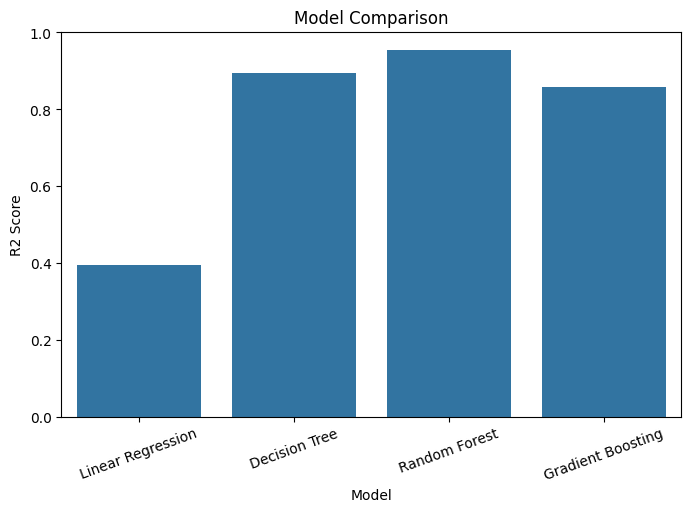

In [31]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.xticks(rotation=20)

plt.title(
    "Model Comparison"
)

plt.savefig(
    "../outputs/model_comparison.png"
)

plt.show()

In [32]:
best_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

best_model.fit(
    X_train,
    y_train
)

predictions = best_model.predict(
    X_test
)

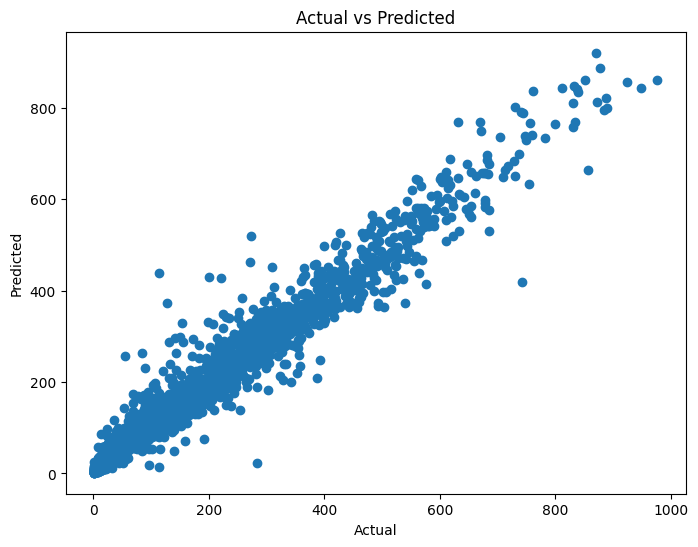

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title(
    "Actual vs Predicted"
)

plt.savefig(
    "../outputs/prediction_plot.png"
)

plt.show()

In [34]:
importance = pd.DataFrame({

    "Feature":
    features,

    "Importance":
    best_model.feature_importances_
})

In [35]:
importance = importance.sort_values(
    by="Importance",
    ascending=False
)

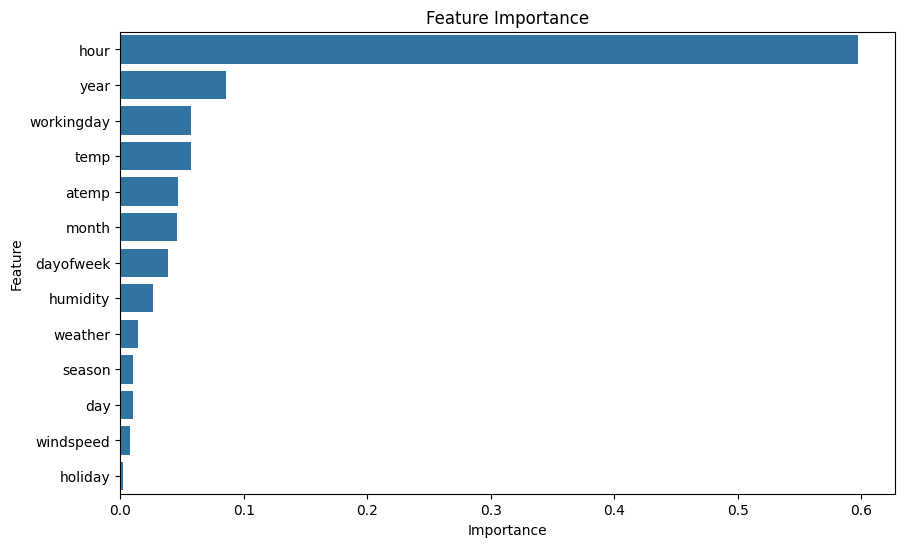

In [36]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "../outputs/feature_importance.png"
)

plt.show()

In [37]:
joblib.dump(
    best_model,
    "../models/best_bike_demand_model.pkl"
)

['../models/best_bike_demand_model.pkl']

In [38]:
print(results_df)

               Model         MAE        RMSE  R2 Score
0  Linear Regression  105.299441  141.210609  0.395871
1      Decision Tree   33.531680   58.689648  0.895644
2      Random Forest   24.188949   38.679437  0.954673
3  Gradient Boosting   46.097955   68.354369  0.858444


In [39]:
print(importance.head(10))

       Feature  Importance
11        hour    0.597708
8         year    0.085980
2   workingday    0.057216
4         temp    0.056895
5        atemp    0.046859
9        month    0.045673
12   dayofweek    0.038751
6     humidity    0.026331
3      weather    0.014058
0       season    0.010500
